# Convex Optimization Examples with CVXPY

This notebook demonstrates how to formulate and solve a variety of convex optimization problems using [CVXPY](https://www.cvxpy.org/), a Python-embedded modeling language for convex optimization. We cover linear programs, quadratic programs, second-order cone programs (SOCPs), semidefinite programs (SDPs), and optimality conditions -- all illustrated with concrete examples.

**Learning objectives.** After working through this notebook you should be able to:
1. Translate a mathematical optimization formulation into CVXPY code.
2. Recognize which problem class (LP, QP, SOCP, SDP) a given formulation belongs to.
3. Interpret solver output (optimal values, optimal solutions, constraint activity).
4. Visualize feasible sets, efficient frontiers, and optimality conditions.

**Prerequisites.** This notebook requires `cvxpy`, `numpy`, and `matplotlib`. Install them with:
```
pip install cvxpy numpy matplotlib
```


# Examples of Convex Optimization


## Linear Programming

### Optimal Transportation Problem

The Optimal Transportation Problem is a classic example of a Linear Program. Suppose we have $ m $ producers (or suppliers) and $ n $ consumers (or demand points). Each producer $ i $ has a supply capacity of $s_i $ and each consumer $ j $ has a demand of $ d_j $. There is a cost $ c_{ij} $ associated with transporting one unit of supply from producer $ i $ to consumer $ j $.

#### Objective
The goal is to determine the amount to be shipped from each producer to each consumer in order to minimize the total transportation cost.

#### Mathematical Formulation
Let
$ x_{ij} $ represent the amount to be shipped from producer \( i \) to consumer \( j \).

Objective Function: Minimize the total transportation cost.
$$
\text{Minimize } \sum_{i=1}^{m} \sum_{j=1}^{n} c_{ij} x_{ij}
$$

Subject to:

1. Supply Constraints: The total amount shipped from each producer should not exceed its supply capacity.
$$
\sum_{j=1}^{n} x_{ij} \leq s_i \quad \text{for all } i=1,2,...,m
$$

2. Demand Constraints: The total amount received by each consumer should meet its demand.
$$
\sum_{i=1}^{m} x_{ij} \geq  d_j \quad \text{for all } j=1,2,...,n
$$

3. Non-negativity Constraints: The amount shipped cannot be negative.
$$
x_{ij} \geq 0 \quad \text{for all } i=1,2,...,m \text{ and } j=1,2,...,n
$$

### CVXPY Implementation

Below is a Python code snippet using CVXPY to solve the optimal transportation problem. You can customize the number of producers, number of consumers, supply capacities, demands, and transportation costs as needed.



In [17]:
import cvxpy as cp
import numpy as np

# Define the number of producers and consumers
m = 3  # number of producers
n = 4  # number of consumers

# Define the supply capacities of the producers
s = np.array([20, 30, 50])  # supply capacities

# Define the demands of the consumers
d = np.array([30, 20, 25, 25])  # demands

# Define the transportation costs between producers and consumers
c = np.array([
    [8, 6, 10, 9],
    [9, 7, 4, 2],
    [3, 4, 2, 7]
])  # transportation costs

# Define the decision variable
x = cp.Variable((m, n), nonneg=True)

# Define the objective function
objective = cp.Minimize(cp.sum(cp.multiply(c, x)))

# Define the constraints
constraints = [
    cp.sum(x, axis=1) <= s,  # supply constraints
    cp.sum(x, axis=0) >= d   # demand constraints
]

# Formulate the linear programming problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Print the optimal value and the optimal solution
print("Optimal Value: ", prob.value)
print("Optimal Solution: \n", x.value)


Optimal Value:  320.0000022066243
Optimal Solution: 
 [[1.86657706e-07 1.99999998e+01 4.50778223e-08 0.00000000e+00]
 [1.56903271e-07 1.79010394e-07 4.99999971e+00 2.49999999e+01]
 [2.99999996e+01 9.20084062e-09 2.00000002e+01 8.31815849e-08]]


### Linear Fractional Programming

Linear Fractional Programming (LFP) involves optimizing a ratio of two linear functions. Given a linear fractional program in the form:

$$
\text{Maximize/Minimize } \frac{{\textbf{c}^T \textbf{x} + d}}{{\textbf{e}^T \textbf{x} + f}}
$$

subject to:

$$
A\textbf{x} \leq \textbf{b}
$$



Where:
- $\textbf{x} $ is the decision variable vector.
- $ \textbf{c} $ and $ \textbf{e} $ are coefficient vectors.
- $ d $ and $ f $ are constants.
- $ A $ is the constraint matrix, and $ \textbf{b} $ is the right-hand side vector.

#### Transformation to Linear Programming

Linear Fractional Programs can be transformed into Linear Programs by using a change of variable. If we define a new variable $ t $ such that:

$$
t = \frac{1}{{\textbf{e}^T \textbf{x} + f}}
$$

Then the objective becomes:
$$
\text{Maximize/Minimize } \textbf{c}^T \textbf{x} + d \cdot z
$$

subject to:

$$
A\textbf{x} - \textbf{b} \cdot z \leq 0
$$
$$
\textbf{e}^T \textbf{x} + f \cdot z  = 1
$$
$$
 z \geq 0
$$
#### Example Problem

Consider an LFP problem where we aim to maximize the following linear fractional function:

$$
\text{Maximize } \frac{{3x_1 + 4x_2 + 5}}{{2x_1 + x_2 + 6}}
$$

subject to:
$$
x_1 + 2x_2 \leq 8
$$

$$
3x_1 + x_2 \leq 9
$$

$$
x_1, x_2 \geq 0
$$



In [15]:


# Define the decision variables
x1 = cp.Variable(pos=True)
x2 = cp.Variable(pos=True)
z = cp.Variable(pos=True)

# Define the coefficients and constants in the objective function
c = np.array([3, 4])
e = np.array([2, 1])
d = 5
f = 6

# Define the constraints
constraints = [
    x1 + 2*x2 - 8*z <=0  ,
    3*x1 + x2 - 9*z <=0 ,
    e[0]*x1 + e[1]*x2 + f*z == 1  # Ensure the denominator is positive
]

# Define the objective function

objective = cp.Maximize(c[0]*x1 + c[1]*x2 + d * z)

# Formulate the linear programming problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Print the optimal value and the optimal solution
print("Optimal Value: ", (c[0]*x1.value + c[1]*x2.value + d * z.value))
print("Optimal Solution: x1 =", x1.value, ", x2 =", x2.value, ", z =", z.value)


Optimal Value:  2.1000000114217836
Optimal Solution: x1 = 0.0 , x2 = 0.4000000023863323 , z = 0.10000000037529086



#### Example: Chebyshev Center
The Chebyshev center of a polytope is the center of the largest inscribed ball within the polytope. Suppose we are given a polytope defined by a set of linear inequalities, and we want to find its Chebyshev center.

#### Mathematical Formulation
Objective:
$$ \text{Maximize } r $$

Subject to:
$ a_i^T x + b_i \geq r \|a_i\|_2 \quad \text{for all } i $

Where:
- $ x $ is the center of the ball.
- $ r $ is the radius of the ball.
- $ a_i^T x + b_i $ represents each linear inequality defining the polytope.
  

In the plot below, the red circle represents the optimal solution, and the blue lines or points represent the given constraints.



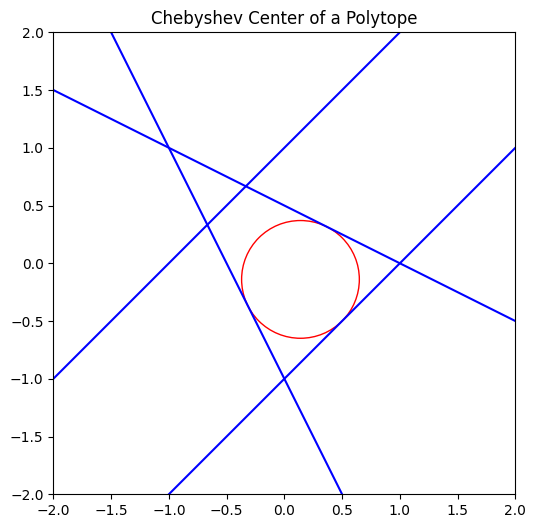

In [18]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the linear inequalities ax + b >= 0 defining the polytope
A = np.array([[2, 1], [1, -1], [-1, -2], [-1, 1]])
b = np.array([1, 1, 1, 1])

# Define the decision variables
x = cp.Variable(2)
r = cp.Variable()

# Define the constraints
constraints = [A[i] @ x + b[i] >= r * cp.norm(A[i]) for i in range(A.shape[0])]

# Define the objective function
objective = cp.Maximize(r)

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Plot the polytope and the Chebyshev center
plt.figure(figsize=(6, 6))
for i in range(A.shape[0]):
    x_vals = np.linspace(-2, 2, 400)
    y_vals = (-A[i, 0] * x_vals - b[i]) / A[i, 1]
    plt.plot(x_vals, y_vals, 'b')
circle = plt.Circle((x.value[0], x.value[1]), r.value, fill=False, color='red')
plt.gca().add_patch(circle)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Chebyshev Center of a Polytope')
plt.show()


## Quadratic Optimization

### Constrained Least-Squares (Lasso)

The Lasso problem is a form of constrained least-squares problem that involves minimizing the sum of squared residuals with an  $\ell_1$-norm constraint on the parameter vector $ \beta$. This constraint induces sparsity in the solution, making Lasso suitable for feature selection in high-dimensional settings.

#### Mathematical Formulation


$$
\text{Minimize } \frac{1}{2} \|X \beta - y\|_2^2
$$
subject to:
$$
\|\beta\|_1 \leq t
$$

where $ t $ is a user-defined parameter controlling the amount of regularization, and hence the sparsity of $\beta $.

#### Example Problem

In this example, we create a random matrix $ X $ of size $ 100 \times 200 $ and a true sparse parameter vector $ \beta $ of size $ 200 $. The response vector $y $ is generated as $ y = X \beta $.




In [19]:
import cvxpy as cp
import numpy as np

# Set the seed for reproducibility
np.random.seed(42)

# Define the dimensions
m, n = 100, 200

# Generate a random matrix X
X = np.random.randn(m, n)

# Generate a true sparse parameter vector beta
beta_true = np.zeros(n)
beta_true[3] = -2
beta_true[7] = 5
beta_true[13] = -3
beta_true[17] = 1
beta_true[23] = -4

# Generate the response vector y
y = X @ beta_true + np.random.normal(scale=0.1, size=m)  # Added noise for realism

# Define the decision variable
beta = cp.Variable(n)

# Define the L1 norm constraint parameter
t = 15 # You can adjust the value of t to control the sparsity of the solution

# Define the objective function
objective = cp.Minimize(0.5 * cp.sum_squares(X @ beta - y))

# Define the constraint
constraint = [cp.norm1(beta) <= t]

# Formulate the quadratic programming problem
prob = cp.Problem(objective, constraint)

# Solve the problem
prob.solve()

# Print the optimal value and the optimal solution
print("Optimal Value: ", prob.value)
print("Optimal Solution (beta): ", beta.value[[3,7,13,17,23]])
print(f"The error of the solution is {np.linalg.norm(beta.value-beta_true, ord = 1)}")

Optimal Value:  0.4665261758977151
Optimal Solution (beta):  [-1.97188975  4.98184204 -2.98219775  0.98770291 -4.00007575]
The error of the solution is 0.17686655837830162


### Markowitz Portfolio Optimization

Markowitz Portfolio Optimization, or Mean-Variance Optimization, is a fundamental approach in finance for portfolio selection. It involves choosing the proportions of different assets in a portfolio in such a way as to make the expected return on the portfolio at least a certain desired level while minimizing the portfolio’s variance of return (i.e., its risk).

#### Mathematical Formulation

Given a set of assets and their expected returns and covariances, the problem can be formulated as follows:

Let:
- $ r $ be the vector of expected returns of the assets.
- $ \Sigma $ be the covariance matrix of the assets' returns.
- $ x $ be the vector of the proportions of the total investment allocated to each asset.
- $ R $ be the desired minimal return.

Objective: Minimize the portfolio variance:
$$ \text{Minimize } x^T \Sigma x $$

Subject to:
1. The expected return should be at least $ R $:
$$ r^T x \geq R $$
2. The proportions should sum up to 1 (full investment):
$$ \sum_i x_i = 1 $$
3. The proportions should be non-negative (no short-selling):
$$ x_i \geq 0 $$


#### Example with 2 Assets

Let’s consider a portfolio with 2 assets, each with given expected returns and a given covariance matrix.  In this 2-asset case, the weight of one asset can be represented on the x-axis, and the weight of the other asset can be inferred as $(x, 1-x)$, where $x$ is the weight assigned to the first asset.


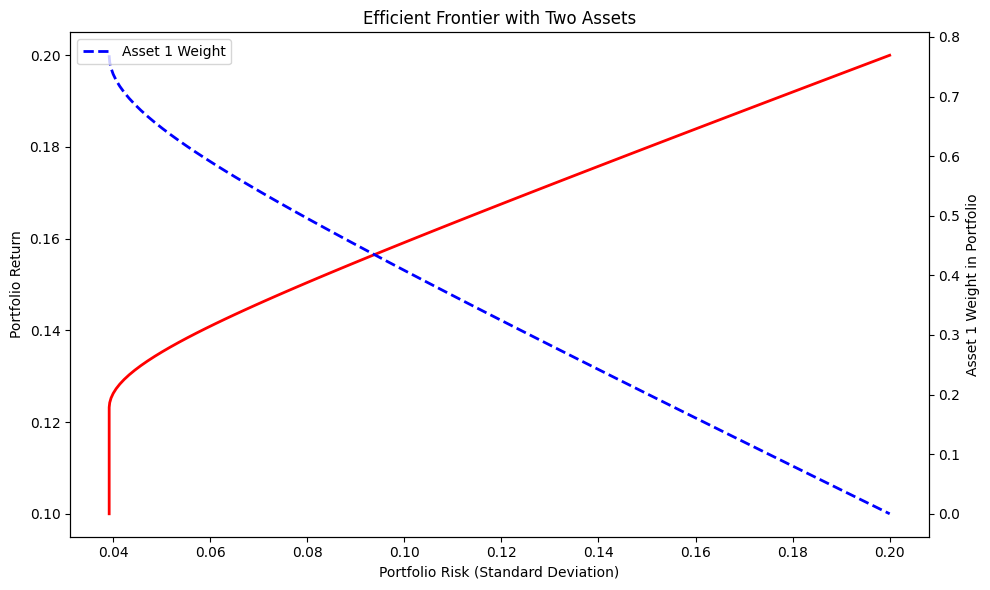

In [27]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the expected returns vector
r = np.array([0.1, 0.2])  # Expected returns of the 2 assets

# Define the covariance matrix
Sigma = np.array([
    [0.005, -0.010],
    [-0.010, 0.040]
])  # Covariance matrix of asset returns

# Define the decision variable
x = cp.Variable()

# Define a range of desired minimal returns
R_values = np.linspace(min(r), max(r), 100)

# Store optimal risk values and optimal x values
risk_values = []
x_values = []

# Solve for various thresholds
for R in R_values:
    weights = cp.vstack([x, 1-x])
    objective = cp.Minimize(cp.quad_form(weights, Sigma))
    constraints = [r.T @ weights >= R]
    prob = cp.Problem(objective, constraints)
    risk_values.append(np.sqrt(prob.solve()))
    x_values.append(x.value)

# Visualize the efficient frontier and optimal asset weights
plt.figure(figsize=(10, 6))
plt.plot(risk_values,  R_values, 'r-', linewidth=2, label='Efficient Frontier')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.title('Efficient Frontier with Two Assets')
plt.twinx()
plt.plot(risk_values, x_values, 'b--', linewidth=2, label='Asset 1 Weight')
plt.ylabel('Asset 1 Weight in Portfolio')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


 Support Vector Machines (SVM) are a class of supervised machine learning algorithms used for classification or regression. When the data is linearly separable, SVM finds the hyperplane that best divides a dataset into classes. The best hyperplane is the one that represents the largest separation, or margin, between the two classes.

### Finding the Separating Hyperplane

Given a set of training examples $ (x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$ where \(x_i \in \mathbb{R}^d\) and $ y_i \in \{-1, 1\}$, the objective of SVM is to find a separating hyperplane in the form:

$ w^\top x + b = 0 $

where $w \in \mathbb{R}^d $ is the weight vector, and \(b\) is the bias.

### The SVM Problem

The problem of finding the optimal separating hyperplane can be formulated as:

1. **Objective:** Maximize the margin while classifying the training data correctly.
   
   The margin \(m\) is given by the formula:
  $ m = \frac{2}{\|w\|} $
   So, minimizing \( \|w\| \) will maximize \(m\).

2. **Subject to:** The constraints that the hyperplane should classify all training examples correctly:
   
   For positive examples (\(y_i = 1\)):
   $ w^\top x_i + b \geq 1 $
   
   For negative examples (\(y_i = -1\)):
   $ w^\top x_i + b \leq -1 $

   This can be combined into one constraint using $y_i$:
   $ y_i(w^\top x_i + b) \geq 1 \quad \forall i $

### Mathematical Formulation:

The SVM problem for strictly separable data can be formulated as:

$$
\begin{align*}
\text{Minimize:} \quad & \frac{1}{2} \|w\|^2 \\
\text{Subject to:} \quad & y_i(w^\top x_i + b) \geq 1 \quad \forall i = 1, \ldots, n
\end{align*}
$$

### Note:

For non-separable data, there are modifications to this basic SVM approach, like introducing slack variables and using the soft-margin SVM formulation. Also, to handle non-linear data, SVM can be extended using kernel methods.

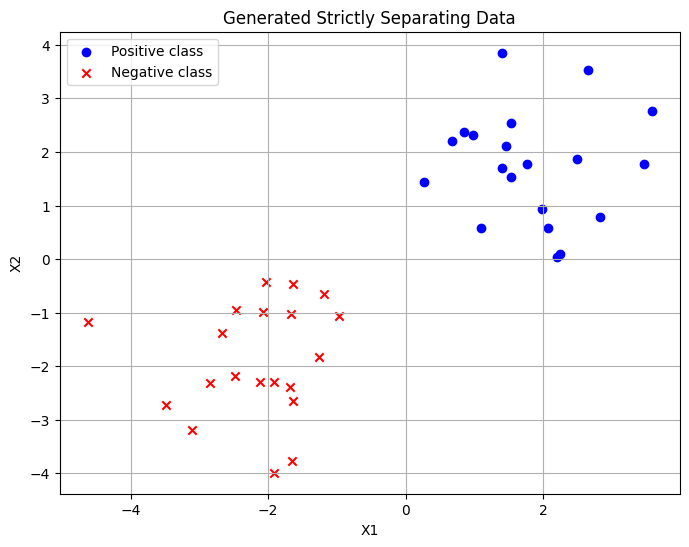

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random strictly separating data
np.random.seed(42)
X_pos = np.random.randn(20, 2) + np.array([2, 2])
X_neg = np.random.randn(20, 2) + np.array([-2, -2])
X = np.vstack([X_pos, X_neg])

y_pos = np.ones(X_pos.shape[0])
y_neg = -np.ones(X_neg.shape[0])
y = np.hstack([y_pos, y_neg])

# Plot the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker='o', color='b', label='Positive class')
plt.scatter(X_neg[:, 0], X_neg[:, 1], marker='x', color='r', label='Negative class')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Generated Strictly Separating Data')
plt.grid(True)
plt.show()


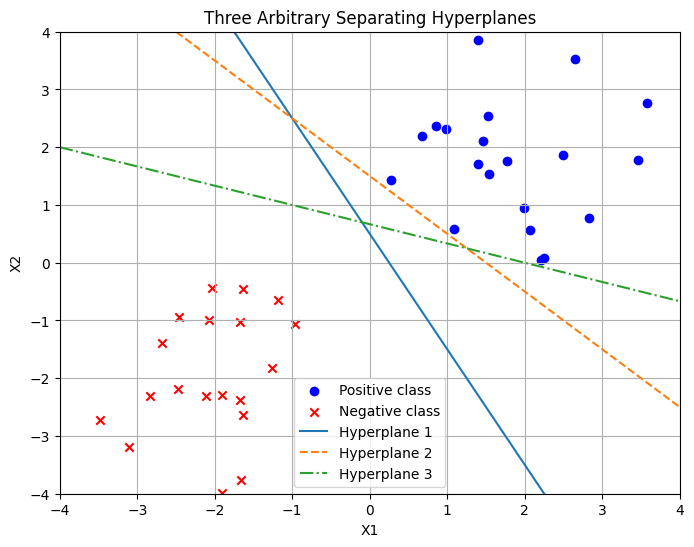

In [22]:
# Define the function to plot the hyperplane
def plot_hyperplane(w, b, label=None, linestyle='-'):
    slope = -w[0] / w[1]
    intercept = -b / w[1]
    x_vals = np.linspace(-4, 4, 400)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, linestyle, label=label)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker='o', color='b', label='Positive class')
plt.scatter(X_neg[:, 0], X_neg[:, 1], marker='x', color='r', label='Negative class')

# Define three arbitrary hyperplanes and plot them
weights = [np.array([-2, -1]), np.array([-1, -1]), np.array([1, 3])]
biases = [0.5, 1.5, -2]
for i, (w, b) in enumerate(zip(weights, biases)):
    plot_hyperplane(w, b, label=f'Hyperplane {i+1}', linestyle=['-', '--', '-.'][i])

plt.xlim([-4, 4])
plt.ylim([-4, 4])
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Three Arbitrary Separating Hyperplanes')
plt.grid(True)
plt.show()


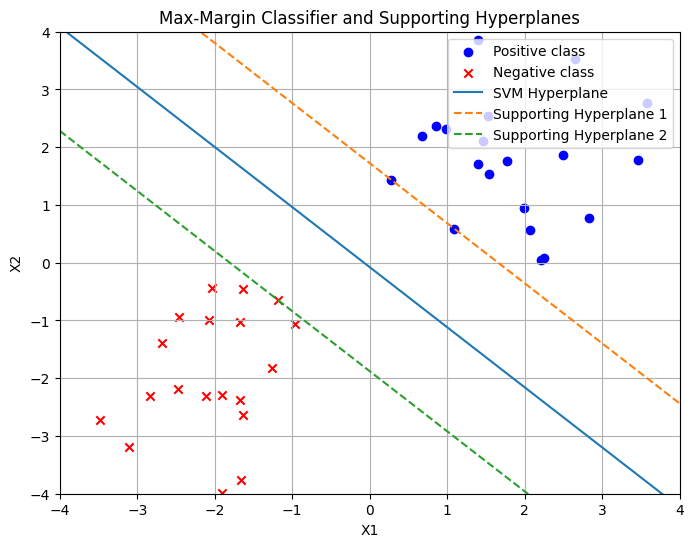

In [23]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Generate random strictly separating data
np.random.seed(42)
X_pos = np.random.randn(20, 2) + np.array([2, 2])
X_neg = np.random.randn(20, 2) + np.array([-2, -2])
X = np.vstack([X_pos, X_neg])

y_pos = np.ones(X_pos.shape[0])
y_neg = -np.ones(X_neg.shape[0])
y = np.hstack([y_pos, y_neg])

# Define the decision variables
w = cp.Variable(2)
b = cp.Variable()

# Define the objective function
objective = cp.Minimize(0.5 * cp.norm(w, 2)**2)

# Define the constraints
constraints = [y[i] * (w.T @ X[i] + b) >= 1 for i in range(X.shape[0])]

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Extract the learned weights and bias
w_svm = w.value
b_svm = b.value

# Function to plot the hyperplane
def plot_hyperplane(w, b, label=None, linestyle='-'):
    slope = -w[0] / w[1]
    intercept = -b / w[1]
    x_vals = np.linspace(-4, 4, 400)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, linestyle, label=label)

# Plot the data and the learned max-margin classifier
plt.figure(figsize=(8, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker='o', color='b', label='Positive class')
plt.scatter(X_neg[:, 0], X_neg[:, 1], marker='x', color='r', label='Negative class')

# Plot the max-margin classifier (SVM hyperplane)
plot_hyperplane(w_svm, b_svm, label='SVM Hyperplane')

# Plot the supporting hyperplanes
plot_hyperplane(w_svm, b_svm - 1, linestyle='--', label='Supporting Hyperplane 1')
plot_hyperplane(w_svm, b_svm + 1, linestyle='--', label='Supporting Hyperplane 2')

plt.xlim([-4, 4])
plt.ylim([-4, 4])
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Max-Margin Classifier and Supporting Hyperplanes')
plt.grid(True)
plt.show()


### Quadratically Constrained Quadratic Programming (QCQP)

Quadratically Constrained Quadratic Programming (QCQP) is a type of optimization problem where both the objective function and the constraints are quadratic functions.

### Example: Portfolio Optimization with a Risk Constraint

To modify the problem to **minimize risk** subject to the following conditions:
1. **Expected return** greater than a given minimum $r_{\text{min}} $.
2. **Factor loading risk** below a threshold.
3. Each asset’s weight is no more than 90%.

Here’s how we can structure this:

### Problem Structure:
- **Objective**: Minimize portfolio risk (variance), which is modeled as $ \text{Risk} = w^T \Sigma w $, where $\Sigma $ is the covariance matrix.
- **Constraints**:
  1. $ \text{Expected return} \geq r_{\text{min}} $.
  2. $ \text{Loading risk} \leq \text{threshold} $ (factor exposure to risk factors).
  3. Each asset’s weight $ w_i \leq 0.9 $ (no more than 90%).


In [35]:
import cvxpy as cp
import numpy as np

# Number of assets
n_assets = 4

# Expected returns
mu = np.array([0.1, 0.2, 0.15, 0.12])  # Expected returns of the assets

# Covariance matrix for portfolio variance (random for this example)
cov_matrix = np.random.rand(n_assets, n_assets)
cov_matrix = cov_matrix.T @ cov_matrix  # Make it symmetric and positive definite

# Factor loading matrix (e.g., market risk, interest rate risk)
F = np.array([
    [0.8, 0.1, 0.4, 0.7],  # Market risk loadings
    [0.2, 0.5, 0.6, 0.1]   # Interest rate risk loadings
])

# Thresholds for constraints
r_min = 0.14  # Minimum required return
loading_threshold = 0.3  # Maximum allowable factor exposure

# Variables
w = cp.Variable(n_assets)  # Portfolio weights

# Objective: Minimize risk (variance)
risk = cp.quad_form(w, cov_matrix)
objective = cp.Minimize(risk)

# Factor exposure constraint: limit overall exposure to the two factors
factor_exposure = cp.quad_form(w, F.T @ F)

# Constraints
constraints = [
    cp.sum(w) == 1,               # Weights sum to 1
    mu @ w >= r_min,              # Expected return >= r_min
    factor_exposure <= loading_threshold,  # Loading risk <= threshold
    w >= 0,                       # Non-negative weights
    w <= 0.9                      # Each asset no more than 90%
]

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
result = problem.solve()

# Check the status of the solver
print("Solver status:", problem.status)

if problem.status == cp.OPTIMAL:
    # Output the results
    print("Optimal weights:", w.value)
    print("Expected return:", (mu @ w).value)
    print("Risk (variance):", risk.value)  # Directly access the scalar value
    print("Factor exposure:", factor_exposure.value)  # Directly access the scalar value
else:
    print("Problem is infeasible or the solver encountered an issue.")


Solver status: optimal
Optimal weights: [9.11025214e-02 9.00000000e-01 8.89747754e-03 1.10451385e-09]
Expected return: 0.1904448738903581
Risk (variance): 0.11667032584942519
Factor exposure: 0.2519607272976754


for r_min = 0.1969387755102041
Solver status: infeasible
for r_min = 0.2
Solver status: infeasible


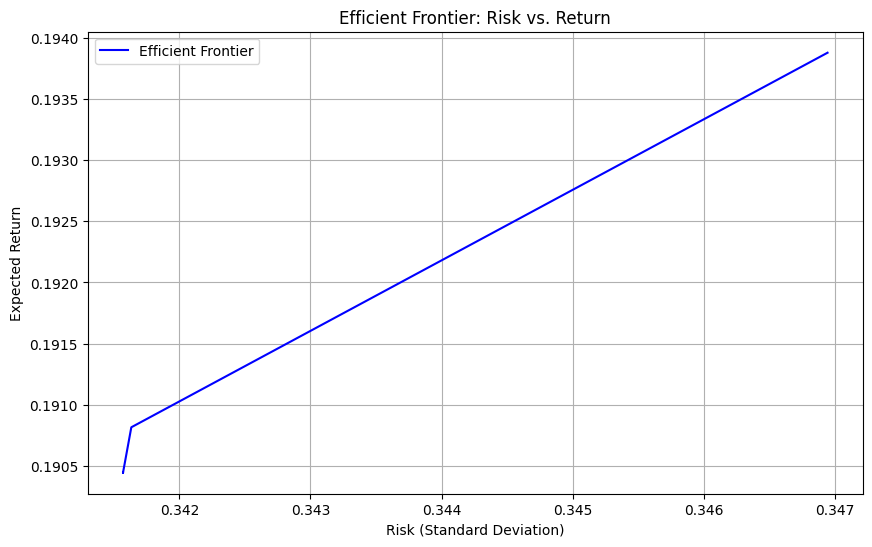

In [38]:
# Arrays to store risk (std dev) and return values
risks = []
returns = []

# Generate a range of minimum required returns
r_min_values = np.linspace(0.05, 0.2, 50)

# Loop through different values of r_min to build the efficient frontier
for r_min in r_min_values:
    # Objective: Minimize risk (variance)
    objective = cp.Minimize(risk)

    # Constraints
    constraints = [
        cp.sum(w) == 1,               # Weights sum to 1
        mu @ w >= r_min,              # Expected return >= r_min
        factor_exposure <= loading_threshold,  # Loading risk <= threshold
        w >= 0,                       # Non-negative weights
        w <= 0.9                      # Each asset no more than 90%
    ]

    # Solve the optimization problem
    problem = cp.Problem(objective, constraints)
    result = problem.solve()

    # Store the risk (std deviation) and return if the problem is feasible
    if problem.status == cp.OPTIMAL:
        risks.append(np.sqrt(risk.value))  # Standard deviation (sqrt of variance)
        returns.append((mu @ w).value)     # Expected return
    else:
        # Check the status of the solver
        print(f"for r_min = {r_min }")
        print("Solver status:", problem.status)

# Plot the efficient frontier
plt.figure(figsize=(10, 6))
plt.plot(risks, returns, 'b-', label='Efficient Frontier')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier: Risk vs. Return')
plt.grid(True)
plt.legend()
plt.show()

### Trust region optimization

We consider the Rosenbrock function. The global minimum is $(1,1)$. This is a nonconvex function.

Iteration 0: Loss = 6.167500166744693, Step norm = 0.7005267988046155, Delta = 1
Iteration 1: Loss = 5.4098932807696105, Step norm = 0.8999999994222653, Delta = 0.9
Iteration 2: Loss = 4.277432881771331, Step norm = 0.2756574296305148, Delta = 0.81
Iteration 3: Loss = 4.018011046718023, Step norm = 0.7289999944840128, Delta = 0.7290000000000001
Iteration 4: Loss = 2.7548906238096635, Step norm = 0.08721559569848197, Delta = 0.6561000000000001
Iteration 5: Loss = 3.3052147985389775, Step norm = 0.590489997330057, Delta = 0.5904900000000002
Iteration 6: Loss = 1.55582064885697, Step norm = 0.11001427291738143, Delta = 0.5314410000000002
Iteration 7: Loss = 4.019018598791992, Step norm = 0.47829689977021134, Delta = 0.47829690000000014
Iteration 8: Loss = 0.6316056420443795, Step norm = 0.1922940512853894, Delta = 0.43046721000000016
Iteration 9: Loss = 1.8823050903306926, Step norm = 0.38742048866580703, Delta = 0.38742048900000015
Iteration 10: Loss = 0.17629346385115574, Step norm = 0.

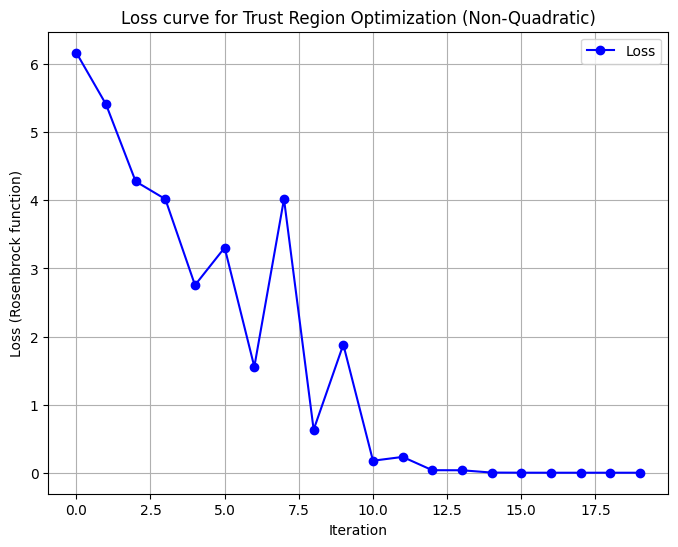

In [54]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the Rosenbrock function
def rosenbrock(x, a=1, b=100):
    x1, x2 = x
    return (a - x1)**2 + b * (x2 - x1**2)**2

# Gradient of the Rosenbrock function
def rosenbrock_gradient(x, a=1, b=100):
    x1, x2 = x
    grad_x1 = -2 * (a - x1) - 4 * b * x1 * (x2 - x1**2)
    grad_x2 = 2 * b * (x2 - x1**2)
    return np.array([grad_x1, grad_x2])

# Hessian of the Rosenbrock function
def rosenbrock_hessian(x, a=1, b=100):
    x1, x2 = x
    h11 = 2 - 4 * b * (x2 - 3 * x1**2)
    h12 = -4 * b * x1
    h21 = h12
    h22 = 2 * b
    return np.array([[h11, h12], [h21, h22]])

# Trust region optimization using second-order Taylor expansion
def trust_region_optimization_non_quadratic(x0, delta, max_iters=20, a=1, b=100):
    x = x0
    losses = []
    iterates = [x0.copy()]
    for k in range(max_iters):
        # Compute the gradient and Hessian at the current point x_k
        grad_f = rosenbrock_gradient(x, a, b)
        H = rosenbrock_hessian(x, a, b)

        # Define the optimization variable (step s)
        s = cp.Variable(x.shape[0])

        # Define the objective function (second-order Taylor expansion)
        obj = cp.Minimize(grad_f.T @ s + 0.5 * cp.quad_form(s, H))

        # Trust region constraint
        constraints = [cp.norm(s, 2) <= delta]

        # Solve the QCQP
        problem = cp.Problem(obj, constraints)
        result = problem.solve()

        if problem.status != cp.OPTIMAL:
            print(f"Iteration {k}: Problem is {problem.status}")
            break

        # Update the current point x_k
        step = s.value
        x = x + step

        # Compute and store the loss at the new point
        loss = rosenbrock(x, a, b)
        losses.append(loss)
        iterates.append(x.copy())
        print(f"Iteration {k}: Loss = {loss}, Step norm = {np.linalg.norm(step)}, Delta = {delta}")

        # Adjust trust region radius based on step size
        if np.linalg.norm(step) == delta:
            delta *= 1.1  # Increase trust region radius if step hits boundary
        else:
            delta *= 0.9  # Decrease trust region radius if step is inside

    return losses, np.array(iterates)

# Initial setup
x0 = np.array([-1.5, 1.5])  # Initial point
delta = 1  # Trust region radius

# Run the trust region optimization
losses, iterates = trust_region_optimization_non_quadratic(x0, delta, max_iters=20)

print(f"The last iterate is {iterates[-1]}")
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(losses, 'b-', marker='o', label='Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Rosenbrock function)')
plt.title('Loss curve for Trust Region Optimization (Non-Quadratic)')
plt.grid(True)
plt.legend()
plt.show()


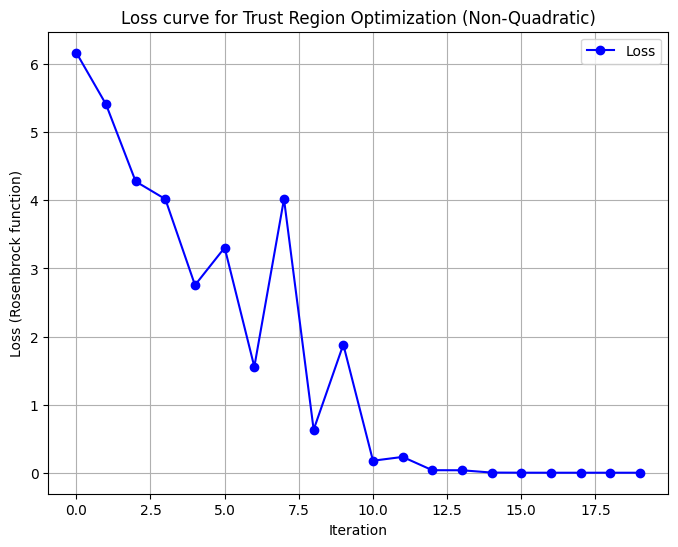

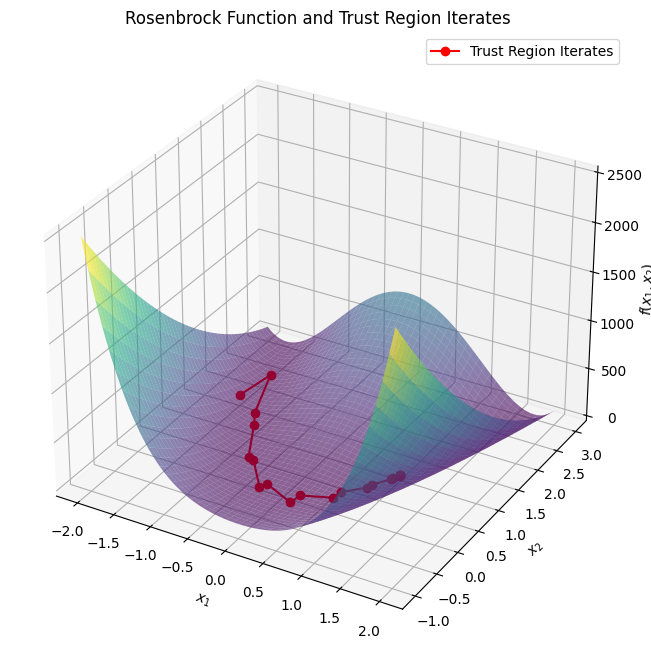

In [55]:
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(losses, 'b-', marker='o', label='Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Rosenbrock function)')
plt.title('Loss curve for Trust Region Optimization (Non-Quadratic)')
plt.grid(True)
plt.legend()
plt.show()

# --- Plot the Rosenbrock Function and the iterates ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a meshgrid for plotting the Rosenbrock surface
x1_vals = np.linspace(-2, 2, 400)
x2_vals = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.array([rosenbrock([x1, x2]) for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
Z = Z.reshape(X1.shape)

# Plot the surface
ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.6)

# Plot the trust region iterates
iter_x1 = iterates[:, 0]
iter_x2 = iterates[:, 1]
iter_z = np.array([rosenbrock([x1, x2]) for x1, x2 in zip(iter_x1, iter_x2)])
ax.plot(iter_x1, iter_x2, iter_z, 'r-o', label='Trust Region Iterates', markersize=6)

# Set labels
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
ax.set_title('Rosenbrock Function and Trust Region Iterates')

plt.legend()
plt.show()


### Second Order Cone Programming (SOCP)

SOCP is a convex optimization problem where the objective is linear, and the feasible set is the intersection of an affine set and the product of second-order (quadratic) cones.

#### Example: Circle Enclosing Points
Suppose we have a set of 2D points, and we want to find the smallest circle that encloses all the points.

Let the circle be represented by its center $ (x, y) $ and radius $ r $. The objective is to minimize the square of the radius $ r^2 $ (to keep it a quadratic problem) such that the distance between each point and the center of the circle is less than or equal to the radius.

#### Mathematical Formulation
Objective:
$ \text{Minimize } r^2 $

Subject to:
$$ \sqrt{ (x_i - x)^2 + (y_i - y)^2} \leq r \quad \text{for all } i $$

In the plot below, the red circle represents the optimal solution, and the blue lines or points represent the given constraints.

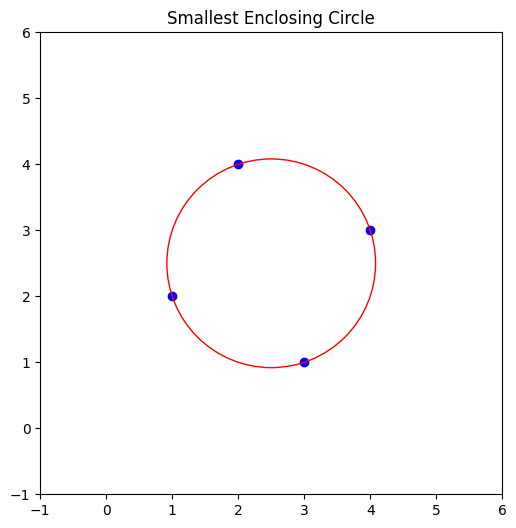

In [28]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the 2D points
points = np.array([[1, 2], [2, 4], [3, 1], [4, 3]])

# Define the decision variables
x = cp.Variable()
y = cp.Variable()
r_squared = cp.Variable()

# Define the constraints
constraints = [cp.norm(cp.vstack([points[i, 0] - x, points[i, 1] - y])) <= cp.sqrt(r_squared) for i in range(points.shape[0])]

# Define the objective function
objective = cp.Minimize(r_squared)

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Plot the points and the enclosing circle
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color='blue')
circle = plt.Circle((x.value, y.value), np.sqrt(r_squared.value), fill=False, color='red')
plt.gca().add_patch(circle)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Smallest Enclosing Circle')
plt.show()


### Example: Robust LP

Consider a robust LP problem in $\mathbb{R}^2$ with two linear inequality constraints. The first constraint has uncertainty. The uncertainty set is $\{ a_1 \colon \|a_1 - \bar a_1 \|_2 \leq 1\}$.

Optimal x:  [-1. -1.]
Optimal value of c^T x:  -1.9999999999385172


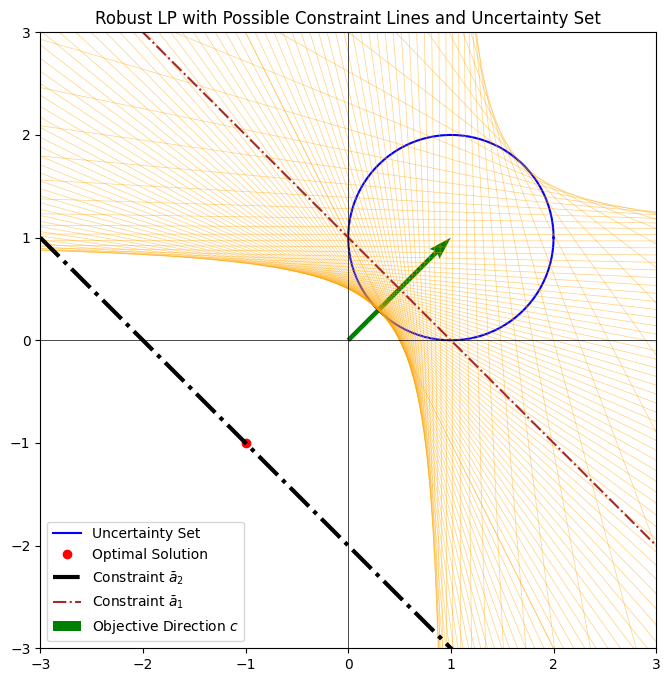

In [64]:
import cvxpy as cp
import numpy as np

# Define the variable
x = cp.Variable(2)

# Given values
c_value = np.array([1.0, 1.0])  # Objective coefficient
a_bar_1 = np.array([1.0, 1.0])  # Center of the uncertainty ellipsoid for the first constraint
a_bar_2 = np.array([-1.0, -1.0])  # Coefficient for the second constraint
Q_value = np.eye(2)  # Uncertainty ellipsoid matrix (Identity for spherical uncertainty)
b_1_value = -1.0  # RHS for the first constraint
b_2_value = -2.0  # RHS for the second constraint

# Define the objective function
objective = cp.Minimize(c_value @ x)

# Define the constraints
constraints = [
    a_bar_1 @ x + b_1_value + cp.norm(Q_value**0.5 @ x) <= 0,
    a_bar_2 @ x + b_2_value <= 0
]

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Get the optimal value of 'x'
optimal_x = x.value
optimal_value = problem.value

print("Optimal x: ", optimal_x)
print("Optimal value of c^T x: ", optimal_value)


# Given values for corrected 2D case visualization
c_value = np.array([1.0, 1.0])  # Objective coefficient
a_bar_1 = np.array([1.0, 1.0])  # Center of the uncertainty ellipsoid for the first constraint
a_bar_2 = np.array([-1.0, -1.0])  # Coefficient for the second constraint
Q_value = np.eye(2)  # Uncertainty ellipsoid matrix (Identity for spherical uncertainty)
b_1_value = -1.0  # RHS for the first constraint
b_2_value = -2.0  # RHS for the second constraint

# Generate points on the uncertainty ellipsoid (spherical in this case)
theta = np.linspace(0, 2 * np.pi, 100)
x_ellipsoid = np.cos(theta)
y_ellipsoid = np.sin(theta)
ellipsoid_points = np.vstack([x_ellipsoid, y_ellipsoid]).T + a_bar_1


# We will find the intersection of the two constraint lines that satisfy both constraints
x_line = np.linspace(-3, 3, 1000)
y_line_1 = -(a_bar_1[0] * x_line + b_1_value) / a_bar_1[1]
y_line_2 = -(a_bar_2[0] * x_line + b_2_value) / a_bar_2[1]
line_points_1 = np.vstack([x_line, y_line_1]).T
line_points_2 = np.vstack([x_line, y_line_2]).T




# Plotting the uncertainty set, possible constraint lines, other constraint line, and objective direction

# Define the figure and axis for plotting
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the uncertainty ellipsoid (Uncertainty Set)
plt.plot(ellipsoid_points[:, 0], ellipsoid_points[:, 1], 'b', label='Uncertainty Set')

plt.plot(optimal_x[0], optimal_x[1], 'ro', label='Optimal Solution')


# Plot several lines representing possible linear constraints for different a in the uncertainty set
num_lines = 100  # Number of lines to draw
for i, theta in enumerate(np.linspace(0, 2 * np.pi, num_lines)):
    a = np.array([np.cos(theta), np.sin(theta)]) + a_bar_1  # a values within the uncertainty set
    y_line = -(a[0] * x_line + b_1_value) / a[1]  # Corresponding constraint lines
    plt.plot(x_line, y_line, color='orange', linestyle='-', linewidth=0.5, alpha=0.5)  # Plotting the lines

# Plot the constraint lines with \bar a
plt.plot(x_line, y_line_2, '-.k', label=r'Constraint $\bar a_2$', linewidth = 3)
plt.plot(x_line, y_line_1, '-.', label=r'Constraint $\bar a_1$', color = 'brown')

# Plot the vector c (Objective Direction)
plt.quiver(0, 0, c_value[0], c_value[1], angles='xy', scale_units='xy', scale=1, color='g', label='Objective Direction $c$')

# Set the plot limits and labels
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('Robust LP with Possible Constraint Lines and Uncertainty Set')
plt.show()




Optimal x:  [9.32909268e-08 4.99999953e-01]
Optimal value of c^T x:  -0.9999999999069636


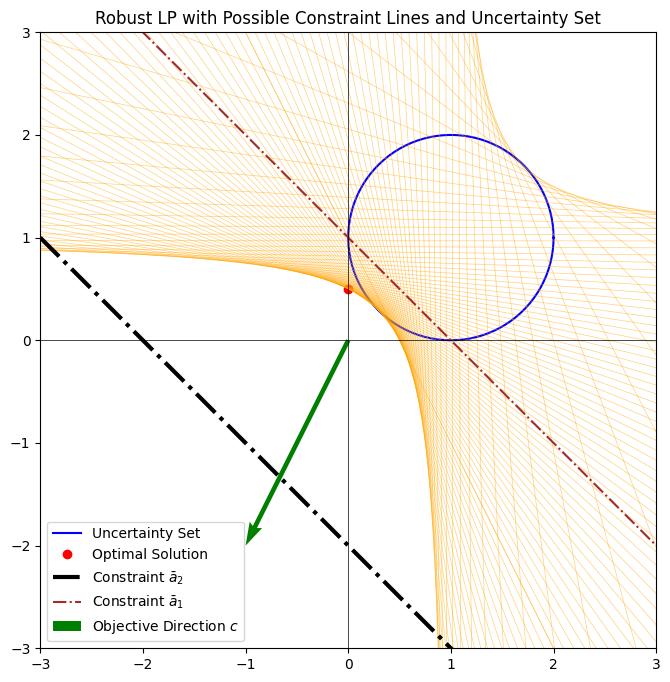

In [65]:
import cvxpy as cp
import numpy as np

# Define the variable
x = cp.Variable(2)

# Given values
c_value = np.array([-1.0, -2.0])  # Objective coefficient
a_bar_1 = np.array([1.0, 1.0])  # Center of the uncertainty ellipsoid for the first constraint
a_bar_2 = np.array([-1.0, -1.0])  # Coefficient for the second constraint
Q_value = np.eye(2)  # Uncertainty ellipsoid matrix (Identity for spherical uncertainty)
b_1_value = -1.0  # RHS for the first constraint
b_2_value = -2.0  # RHS for the second constraint

# Define the objective function
objective = cp.Minimize(c_value @ x)

# Define the constraints
constraints = [
    a_bar_1 @ x + b_1_value + cp.norm(Q_value**0.5 @ x) <= 0,
    a_bar_2 @ x + b_2_value <= 0
]

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Get the optimal value of 'x'
optimal_x = x.value
optimal_value = problem.value

print("Optimal x: ", optimal_x)
print("Optimal value of c^T x: ", optimal_value)




# Generate points on the uncertainty ellipsoid (spherical in this case)
theta = np.linspace(0, 2 * np.pi, 100)
x_ellipsoid = np.cos(theta)
y_ellipsoid = np.sin(theta)
ellipsoid_points = np.vstack([x_ellipsoid, y_ellipsoid]).T + a_bar_1


# We will find the intersection of the two constraint lines that satisfy both constraints
x_line = np.linspace(-3, 3, 1000)
y_line_1 = -(a_bar_1[0] * x_line + b_1_value) / a_bar_1[1]
y_line_2 = -(a_bar_2[0] * x_line + b_2_value) / a_bar_2[1]
line_points_1 = np.vstack([x_line, y_line_1]).T
line_points_2 = np.vstack([x_line, y_line_2]).T




# Plotting the uncertainty set, possible constraint lines, other constraint line, and objective direction

# Define the figure and axis for plotting
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the uncertainty ellipsoid (Uncertainty Set)
plt.plot(ellipsoid_points[:, 0], ellipsoid_points[:, 1], 'b', label='Uncertainty Set')

plt.plot(optimal_x[0], optimal_x[1], 'ro', label='Optimal Solution')


# Plot several lines representing possible linear constraints for different a in the uncertainty set
num_lines = 100  # Number of lines to draw
for i, theta in enumerate(np.linspace(0, 2 * np.pi, num_lines)):
    a = np.array([np.cos(theta), np.sin(theta)]) + a_bar_1  # a values within the uncertainty set
    y_line = -(a[0] * x_line + b_1_value) / a[1]  # Corresponding constraint lines
    plt.plot(x_line, y_line, color='orange', linestyle='-', linewidth=0.5, alpha=0.5)  # Plotting the lines

# Plot the constraint lines with \bar a
plt.plot(x_line, y_line_2, '-.k', label=r'Constraint $\bar a_2$', linewidth = 3)
plt.plot(x_line, y_line_1, '-.', label=r'Constraint $\bar a_1$', color = 'brown')

# Plot the vector c (Objective Direction)
plt.quiver(0, 0, c_value[0], c_value[1], angles='xy', scale_units='xy', scale=1, color='g', label='Objective Direction $c$')

# Set the plot limits and labels
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('Robust LP with Possible Constraint Lines and Uncertainty Set')
plt.show()




### Semidefinite Programming (SDP)

Semidefinite Programming is an optimization model where the variable is a symmetric matrix, and both the objective function and the constraints are linear with respect to the entries of this matrix. It generalizes linear programming and is used to solve many problems in various fields, such as quantum mechanics, control theory, and machine learning.

#### Example: Relaxation of Computing the Leading Eigenvector

The leading eigenvector of a symmetric matrix corresponds to its largest eigenvalue. The problem of finding the leading eigenvector can be relaxed into an SDP.

Given a symmetric matrix $ A $, the original problem can be formulated as:

$$ \text{Maximize } x^T A x $$
$$ \text{subject to } \|x\|_2 = 1 $$

This can be relaxed to an SDP as follows:

$$ \text{Maximize } \text{trace}(AX)$$
$$ \text{subject to } X \succeq 0, \text{trace}(X) = 1 $$

Where:
- $ X $ is a symmetric positive semidefinite matrix.
- $ \text{trace}(AX) $ is the trace of the matrix $ AX $, and it stands for the quadratic form $ x^T A x $.

#### Visualization Example: 2x2 Matrix

For a 2x2 symmetric matrix \( A \), we can visualize the feasible set and the optimal solution in a 2D space.


In [13]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define a 2x2 symmetric matrix A
A = np.array([[2, 1], [1, 6]])

# Define the decision variable
X = cp.Variable((2, 2), symmetric=True)

# Define the constraints
constraints = [X >> 0, cp.trace(X) == 1]

# Define the objective function
objective = cp.Maximize(cp.trace(A @ X))

# Formulate the SDP problem
prob = cp.Problem(objective, constraints)

# Solve the SDP problem
prob.solve()

# Extract the optimal X
optimal_X = X.value

print(f"the eigenvalue and eigenvector computed by SDP are {optimal_X}, {prob.value}")


# Find the eigenvalues and eigenvectors via numpy
eigvals, eigvecs = np.linalg.eig(A)

# Print the leading eigenvalue and eigenvector
print(f"numpy gives us {np.outer(eigvecs[:, 1], eigvecs[:, 1]) } and {eigvals[1]}")

the eigenvalue and eigenvector computed by SDP are [[0.05278641 0.2236068 ]
 [0.2236068  0.94721359]], 6.2360679624008535
numpy gives us [[0.0527864 0.2236068]
 [0.2236068 0.9472136]] and 6.23606797749979


# Optimality Condition

### Optimality Condition for Differentiable Convex Objective

Given a differentiable convex objective function $ f: \mathbb{R}^n \rightarrow \mathbb{R} $ subject to a constraint, a point $ x $ is optimal if the following condition holds:

$$
\nabla f(x)^\top (y - x) \geq 0
$$

for all $ y $ in the feasible region. This condition states that the gradient of the objective function at the optimal point, transposed and dotted with the vector from the optimal point to any other point in the feasible region, is non-negative.

### Visualization Example:

Let’s consider a simple problem where the objective is to minimize a quadratic function subject to a elipse constraint.

#### Mathematical Formulation


**Objective:**
$$ \text{Minimize } \; f(x, y) = x^2 + y^2 $$

**Subject to:**
$$ \left( \frac{x - a}{r_x} \right)^2 + \left( \frac{y - b}{r_y} \right)^2 \leq 1 $$

Here, $ (a, b) $ is the center of the ellipse, and $ r_x, r_y $ are the semi-major and semi-minor axes, respectively.



In this example, the optimal solution will be on the boundary of the ellipse, as we are minimizing the square of the distance from the origin, subject to the constraint that the point must be within the ellipse. The visualization will show the feasible set, the contours of the objective function, and the optimal point on the boundary of the feasible set.


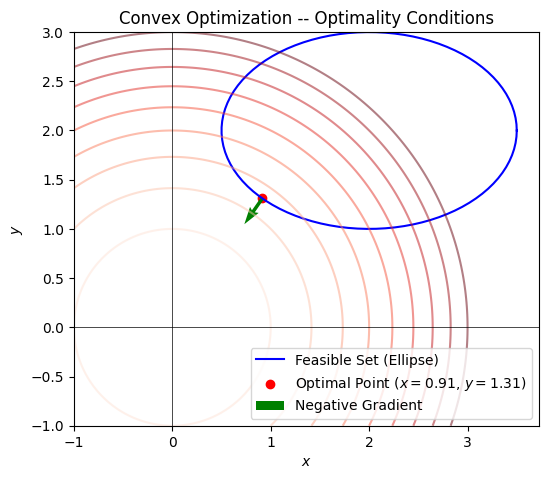

In [68]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the decision variables
x = cp.Variable()
y = cp.Variable()

# Define the objective function (minimize the distance from the origin, i.e., minimize x^2 + y^2)
objective = cp.Minimize(x**2 + y**2)

# Define the ellipse parameters
a, b = 2, 2  # Center of the ellipse
rx, ry = 1.5, 1  # Semi-major and semi-minor axes

# Define the constraint (x, y should be inside the ellipse)
constraints = [((x - a) / rx)**2 + ((y - b) / ry)**2 <= 1]

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Extract the optimal point
x_opt, y_opt = x.value, y.value

# Plot the feasible set, objective contours, and optimal point
theta = np.linspace(0, 2 * np.pi, 100)
plt.figure(figsize=(6, 6))
plt.plot(a + rx * np.cos(theta), b + ry * np.sin(theta), 'b-', label='Feasible Set (Ellipse)')  # Ellipse

# Create a meshgrid for contour plot
X, Y = np.meshgrid(np.linspace(-1, 3, 100), np.linspace(-1, 3, 100))
Z = X**2 + Y**2

plt.contour(X, Y, Z, levels=np.linspace(0, 9, 10), cmap='Reds', alpha=0.5)  # Contour plot of the objective
plt.scatter([x_opt], [y_opt], color='red', label=f'Optimal Point ($x={x_opt:.2f}$, $y={y_opt:.2f}$)')  # Optimal point

# Plot the negative gradient at the optimal point
gradient_x, gradient_y = -2 * x_opt, -2 * y_opt
plt.quiver(x_opt, y_opt, 0.1* gradient_x, 0.1* gradient_y, color='green', angles='xy', scale_units='xy', scale=1, label='Negative Gradient')

# Additional plot settings
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Convex Optimization -- Optimality Conditions')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()


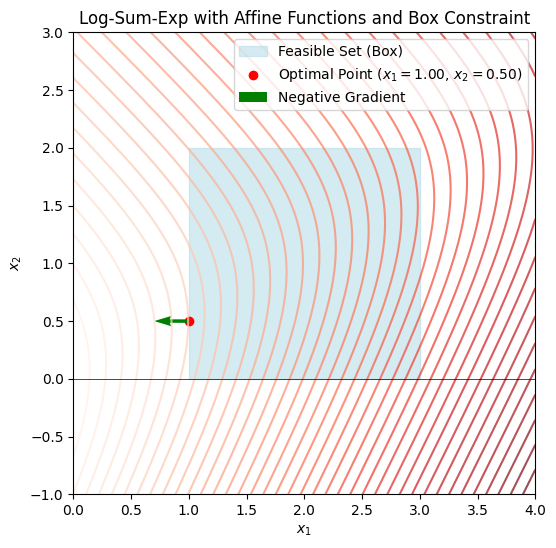

In [86]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the decision variables
x1 = cp.Variable()
x2 = cp.Variable()

# Define the log-sum-exp objective function (using cp.vstack to handle multiple expressions)
objective = cp.Minimize(cp.log_sum_exp(cp.vstack([x1 + x2, 2 * x1 - x2])))

# Define the box constraints
constraints = [x1 >= 1, x1 <= 3, x2 >= 0, x2 <= 2]

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Extract the optimal point
x1_opt, x2_opt = x1.value, x2.value

# Plot the feasible set (box constraint), objective contours, and optimal point
plt.figure(figsize=(6, 6))

# Box (feasible region)
plt.fill_between([1, 3], 0, 2, color='lightblue', alpha=0.5, label='Feasible Set (Box)')

# Create a meshgrid for contour plot
X1, X2 = np.meshgrid(np.linspace(0, 4, 1000), np.linspace(-1, 3, 1000))
Z = np.log(np.exp(X1 + X2) + np.exp(2 * X1 - X2))

# Contour plot of the objective
plt.contour(X1, X2, Z, levels=np.linspace(Z.min(), Z.max(), 40), cmap='Reds', alpha=0.7)

# Plot the optimal point
plt.scatter([x1_opt], [x2_opt], color='red', label=f'Optimal Point ($x_1={x1_opt:.2f}$, $x_2={x2_opt:.2f}$)')

# Plot the negative gradient at the optimal point (derived from the objective)
grad_x1 = np.exp(x1_opt + x2_opt) / (np.exp(x1_opt + x2_opt) + np.exp(2 * x1_opt - x2_opt)) + \
          2 * np.exp(2 * x1_opt - x2_opt) / (np.exp(x1_opt + x2_opt) + np.exp(2 * x1_opt - x2_opt))
grad_x2 = np.exp(x1_opt + x2_opt) / (np.exp(x1_opt + x2_opt) + np.exp(2 * x1_opt - x2_opt)) - \
          np.exp(2 * x1_opt - x2_opt) / (np.exp(x1_opt + x2_opt) + np.exp(2 * x1_opt - x2_opt))
plt.quiver(x1_opt, x2_opt, -0.2* grad_x1, -0.2* grad_x2, color='green', angles='xy', scale_units='xy', scale=1, label='Negative Gradient')

# Additional plot settings
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim([0, 4])
plt.ylim([-1, 3])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Log-Sum-Exp with Affine Functions and Box Constraint')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()


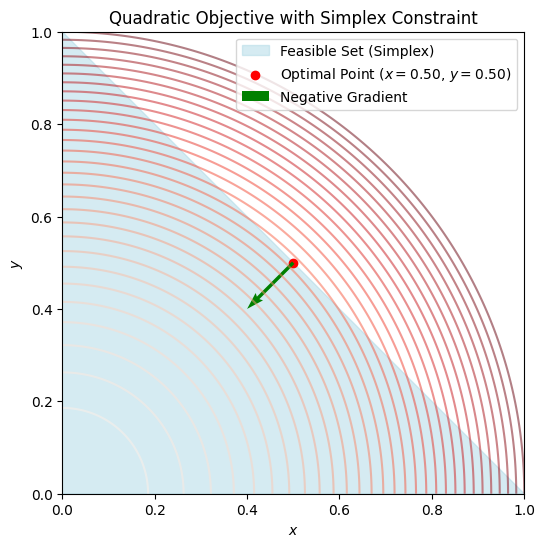

In [84]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define the decision variables
x = cp.Variable()
y = cp.Variable()

# Define the objective function (minimize x^2 + y^2)
objective = cp.Minimize(x**2 + y**2)

# Define the simplex constraint (x + y = 1, x >= 0, y >= 0)
constraints = [x + y == 1, x >= 0, y >= 0]

# Formulate the problem
prob = cp.Problem(objective, constraints)

# Solve the problem
prob.solve()

# Extract the optimal point
x_opt, y_opt = x.value, y.value

# Plot the feasible set (simplex), objective contours, and optimal point
plt.figure(figsize=(6, 6))

# Simplex (feasible region)
simplex_x = [0, 1, 0]
simplex_y = [1, 0, 0]
plt.fill(simplex_x, simplex_y, color='lightblue', alpha=0.5, label='Feasible Set (Simplex)')

# Create a meshgrid for contour plot
X, Y = np.meshgrid(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000))
Z = X**2 + Y**2

plt.contour(X, Y, Z, levels=np.linspace(0, 1, 30), cmap='Reds', alpha=0.5)  # Contour plot of the objective
plt.scatter([x_opt], [y_opt], color='red', label=f'Optimal Point ($x={x_opt:.2f}$, $y={y_opt:.2f}$)')  # Optimal point

# Plot the negative gradient at the optimal point
gradient_x, gradient_y = -2 * x_opt, -2 * y_opt
plt.quiver(x_opt, y_opt, 0.1* gradient_x, 0.1* gradient_y, color='green', angles='xy', scale_units='xy', scale=1, label='Negative Gradient')

# Additional plot settings
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Quadratic Objective with Simplex Constraint')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()


## Summary

**Key takeaways from this notebook:**

1. **CVXPY workflow.** Define decision variables, write the objective and constraints using CVXPY atoms, form a `Problem`, and call `solve()`. CVXPY verifies convexity via disciplined convex programming (DCP) rules and selects an appropriate solver automatically.

2. **Linear programming.** We solved the optimal transportation problem (minimizing shipping cost subject to supply/demand constraints), a linear fractional program (converted to an LP via a change of variables), and the Chebyshev center problem (finding the largest inscribed ball in a polytope).

3. **Quadratic and quadratically constrained programming.** The Lasso ($\ell_1$-constrained least squares) recovers sparse signals. Markowitz portfolio optimization traces the efficient frontier. QCQP handles quadratic constraints such as factor-loading risk bounds. Trust-region methods solve nonconvex problems via local convex (quadratic) approximations.

4. **SOCP and SDP.** The minimum enclosing circle is an SOCP. Robust LP with ellipsoidal uncertainty reduces to SOCP. Computing the leading eigenvector relaxes to an SDP.

5. **Optimality conditions.** For a differentiable convex objective over a convex feasible set, optimality is characterized by $\nabla f(x^\star)^\top (y - x^\star) \geq 0$ for all feasible $y$. The negative gradient at the optimum points into the feasible set.